# Trabalho - Rede Neural Artificial

Baseado no `exemplo4.py` da aula. A ideia e comparar a rede apresentada em aula com uma versao modificada (mais amostras, mais ruido, mais neuronios e uma camada oculta a mais) num problema de classificacao nao linear.

In [ ]:
# Baseado no exemplo4.py da aula de 21/08. Mantivemos make_moons, o
# otimizador SGD e o erro quadratico medio pra manter a comparacao justa.

from sklearn import datasets
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Dense, Input
from keras.optimizers import SGD
from keras.utils import set_random_seed

## Configuracao do experimento

In [2]:
SEED = 42
set_random_seed(SEED)

N_AMOSTRAS = 500
RUIDO = 0.20
TAXA_APRENDIZADO = 0.1
EPOCAS = 200
BATCH_SIZE = 10

## Base de dados

O exemplo4.py usa make_moons(100, noise=0.1). Aqui aumentamos a quantidade de amostras e o ruido pra deixar a classificacao um pouco mais dificil.

In [3]:
X, Y = datasets.make_moons(
    n_samples=N_AMOSTRAS,
    noise=RUIDO,
    random_state=SEED,
)

X_treino, X_teste, Y_treino, Y_teste = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=SEED,
    stratify=Y,
)

## Visualizacao da base

In [4]:
def salvar_grafico_base():
    plt.figure(figsize=(7, 5))
    plt.scatter(X[:, 0], X[:, 1], c=Y)
    plt.xlabel("x0")
    plt.ylabel("x1")
    plt.title("Base make_moons - 500 amostras e ruido 0.20")
    plt.tight_layout()
    plt.savefig("../figuras/01_base_make_moons.png", dpi=150)
    plt.show()
    plt.close()

## Modelo de referencia

Mesma estrutura da parte em Keras do exemplo4.py.

In [5]:
def criar_modelo_referencia():
    modelo = Sequential([
        Input(shape=(2,)),
        Dense(5, activation="relu"),
        Dense(5, activation="tanh"),
        Dense(1, activation="sigmoid"),
    ])

    otimizador = SGD(learning_rate=TAXA_APRENDIZADO)
    modelo.compile(
        loss="mean_squared_error",
        optimizer=otimizador,
        metrics=["accuracy"],
    )
    return modelo

## Modelo proposto

In [6]:
def criar_modelo_proposto():
    # mais neuronios, uma camada oculta a mais e ReLU nas duas primeiras
    # camadas em vez de so na primeira
    modelo = Sequential([
        Input(shape=(2,)),
        Dense(16, activation="relu"),
        Dense(8, activation="relu"),
        Dense(4, activation="tanh"),
        Dense(1, activation="sigmoid"),
    ])

    otimizador = SGD(learning_rate=TAXA_APRENDIZADO)
    modelo.compile(
        loss="mean_squared_error",
        optimizer=otimizador,
        metrics=["accuracy"],
    )
    return modelo

## Treinamento

In [7]:
def treinar_modelo(modelo, nome):
    print(f"\n{nome}")
    modelo.summary()

    historico = modelo.fit(
        X_treino,
        Y_treino,
        validation_data=(X_teste, Y_teste),
        epochs=EPOCAS,
        batch_size=BATCH_SIZE,
        verbose=0,
    )

    loss, acc = modelo.evaluate(X_teste, Y_teste, verbose=0)
    print(f"Loss no teste: {loss:.6f}")
    print(f"Acuracia no teste: {acc:.4f} ({acc * 100:.2f}%)")

    return historico, loss, acc

## Graficos de treinamento

In [8]:
def salvar_curvas(historico, nome_arquivo, titulo):
    plt.figure(figsize=(7, 5))
    plt.plot(historico.history["loss"], label="Treino")
    plt.plot(historico.history["val_loss"], label="Teste")
    plt.xlabel("Epoca")
    plt.ylabel("Loss")
    plt.title(f"Loss - {titulo}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{nome_arquivo}_loss.png", dpi=150)
    plt.show()
    plt.close()

    plt.figure(figsize=(7, 5))
    plt.plot(historico.history["accuracy"], label="Treino")
    plt.plot(historico.history["val_accuracy"], label="Teste")
    plt.xlabel("Epoca")
    plt.ylabel("Acuracia")
    plt.title(f"Acuracia - {titulo}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{nome_arquivo}_acuracia.png", dpi=150)
    plt.show()
    plt.close()

## Fronteira de decisao

In [9]:
def salvar_fronteira_decisao(modelo, nome_arquivo, titulo):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )

    grade = np.c_[xx.ravel(), yy.ravel()]
    probabilidades = modelo.predict(grade, verbose=0).reshape(xx.shape)
    classes = (probabilidades >= 0.5).astype(int)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, classes, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=Y)
    plt.xlabel("x0")
    plt.ylabel("x1")
    plt.title(f"Fronteira de decisao - {titulo}")
    plt.tight_layout()
    plt.savefig(nome_arquivo, dpi=150)
    plt.show()
    plt.close()

## Execucao

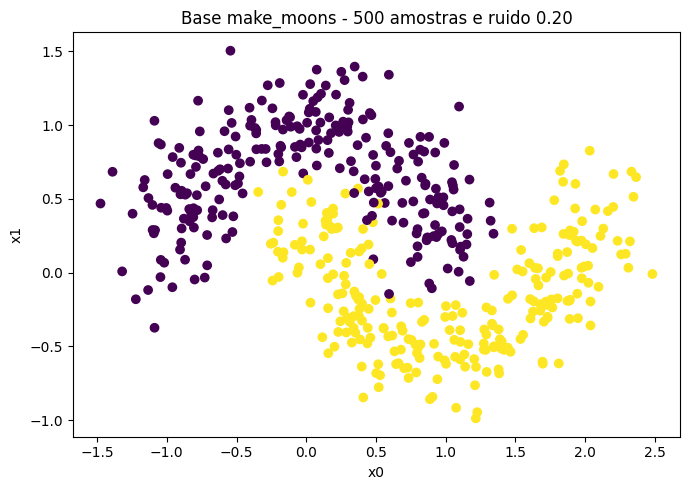


Modelo de referencia (5 ReLU -> 5 tanh -> 1 sigmoid)
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 5)                 15        
                                                                 
 dense_1 (Dense)             (None, 5)                 30        
                                                                 
 dense_2 (Dense)             (None, 1)                 6         
                                                                 
Total params: 51 (204.00 Byte)
Trainable params: 51 (204.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Loss no teste: 0.012728
Acuracia no teste: 0.9900 (99.00%)

Modelo proposto (16 ReLU -> 8 ReLU -> 4 tanh -> 1 sigmoid)
Model: "sequential_1"
_________________________________________________________________
 Layer (type)          

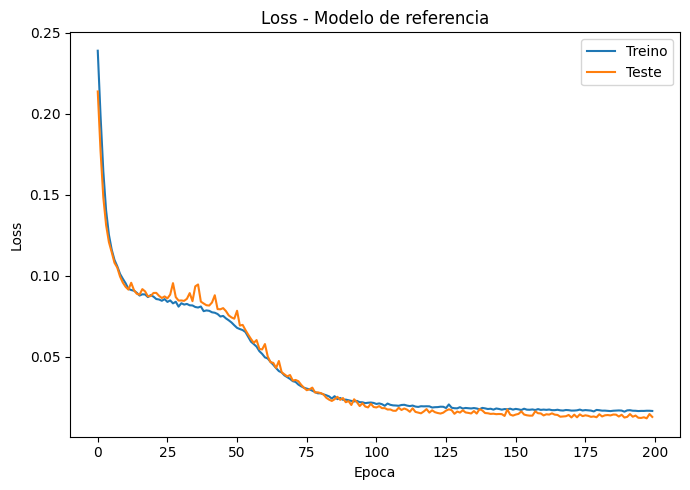

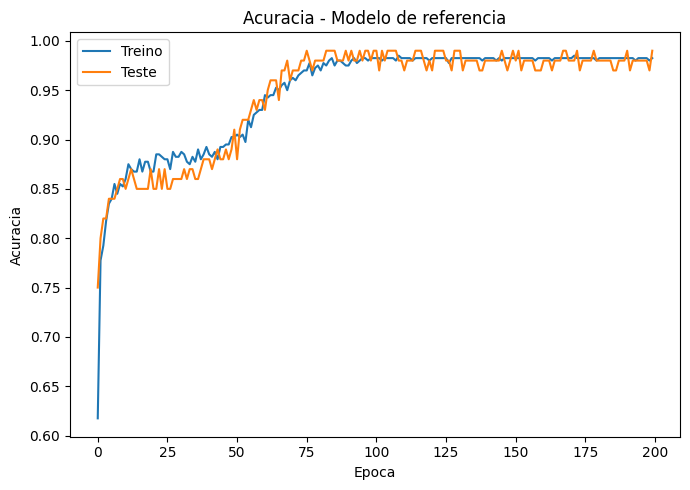

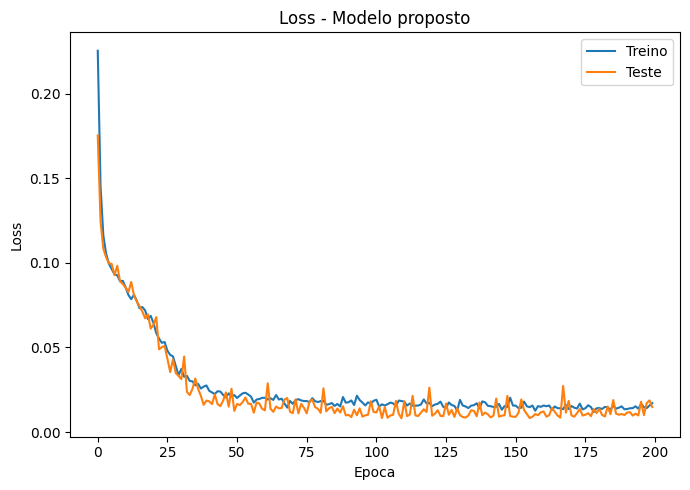

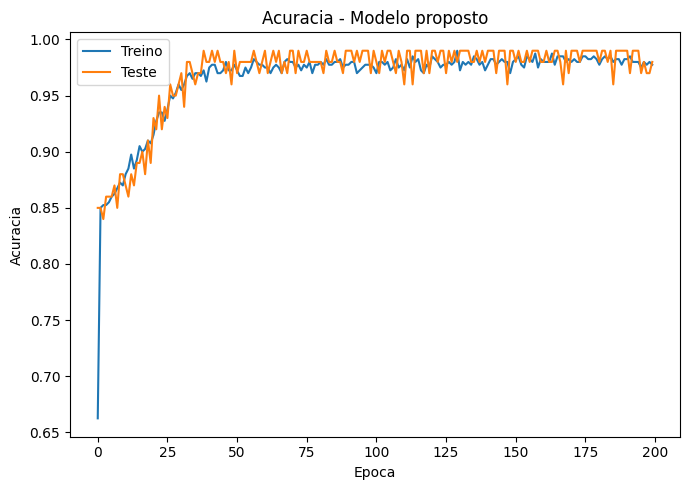

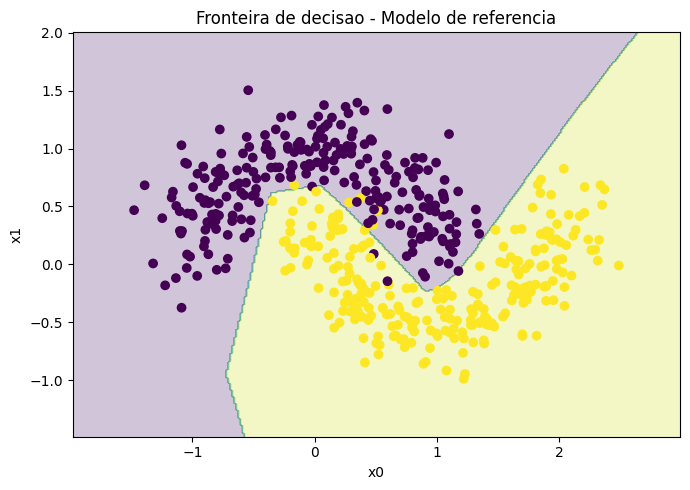

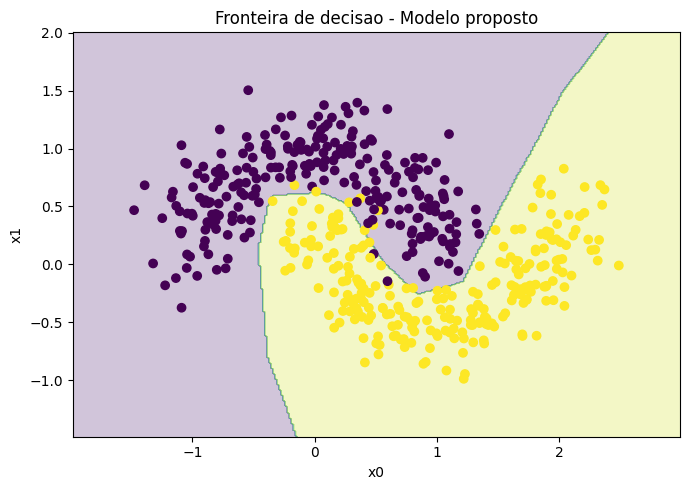


Resumo
Base: make_moons(500, noise=0.2), treino=400, teste=100
Referencia -> loss=0.012728 | acc=99.00%
Proposto   -> loss=0.014799 | acc=98.00%
O modelo proposto ficou 1.00 ponto(s) percentual(is) abaixo em acuracia.


In [10]:
def main():
    salvar_grafico_base()

    modelo_referencia = criar_modelo_referencia()
    hist_ref, loss_ref, acc_ref = treinar_modelo(
        modelo_referencia, "Modelo de referencia (5 ReLU -> 5 tanh -> 1 sigmoid)"
    )

    modelo_proposto = criar_modelo_proposto()
    hist_prop, loss_prop, acc_prop = treinar_modelo(
        modelo_proposto, "Modelo proposto (16 ReLU -> 8 ReLU -> 4 tanh -> 1 sigmoid)"
    )

    salvar_curvas(hist_ref, "../figuras/02_modelo_referencia", "Modelo de referencia")
    salvar_curvas(hist_prop, "../figuras/03_modelo_proposto", "Modelo proposto")

    salvar_fronteira_decisao(
        modelo_referencia, "../figuras/04_fronteira_modelo_referencia.png", "Modelo de referencia"
    )
    salvar_fronteira_decisao(
        modelo_proposto, "../figuras/05_fronteira_modelo_proposto.png", "Modelo proposto"
    )

    print("\nResumo")
    print(f"Base: make_moons({N_AMOSTRAS}, noise={RUIDO}), treino={len(X_treino)}, teste={len(X_teste)}")
    print(f"Referencia -> loss={loss_ref:.6f} | acc={acc_ref * 100:.2f}%")
    print(f"Proposto   -> loss={loss_prop:.6f} | acc={acc_prop * 100:.2f}%")

    diferenca = (acc_prop - acc_ref) * 100
    if diferenca > 0:
        print(f"O modelo proposto ficou {diferenca:.2f} ponto(s) percentual(is) acima em acuracia.")
    elif diferenca < 0:
        print(f"O modelo proposto ficou {abs(diferenca):.2f} ponto(s) percentual(is) abaixo em acuracia.")
    else:
        print("Os dois modelos tiveram a mesma acuracia no teste.")


main()

## Analise dos resultados

O modelo proposto teve acuracia um pouco menor que a referencia (98% contra 99%, errou 1 amostra a mais em 100 no teste) e loss final um pouco maior (0.0148 contra 0.0127).

Nas curvas de loss, o modelo proposto converge mais rapido: ja estabiliza perto de 0.02 por volta da epoca 40-50, enquanto a referencia so chega num patamar parecido perto da epoca 100-125. Faz sentido, ja que a rede maior tem mais parametros pra ajustar com o mesmo SGD. Em nenhum dos dois casos a loss de teste ficou visivelmente pior que a de treino, entao nao ha sinal de overfitting.

As fronteiras de decisao dos dois modelos ficaram bem parecidas e acompanham bem o formato das duas luas. A diferenca aparece perto do cruzamento entre as classes (x0 entre -0.5 e 0), onde o modelo proposto faz uma transicao mais abrupta, quase vertical - provavelmente e essa regiao que concentra a diferenca de acuracia.

Conclusao: pra esse problema e esse nivel de ruido, a rede do exemplo da aula ja era suficiente. Aumentar neuronios e camadas fez o treino convergir mais rapido, mas nao trouxe ganho de acuracia - pelo contrario, piorou levemente, possivelmente porque a capacidade extra deixou o modelo mais sensivel ao ruido perto da fronteira entre as classes.